In [1]:
# ============================================================
# 1. IMPORTS + CONFIGURATION
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler

import albumentations as A
from albumentations.pytorch import ToTensorV2

import timm  # EfficientNet models

# DEVICE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# CONFIG
# ============================================================

CONFIG = {
    "root": r"C:/Users/sudhe/Downloads/archive/",
    "img_size": 256,
    "batch_size": 8,
    "epochs_frozen": 3,
    "epochs_unfrozen": 15,
    "folds": 3,
    "classes": ['akiec','bcc','bkl','df','mel','nv','vasc']
}

print(CONFIG)


Using device: cuda
{'root': 'C:/Users/sudhe/Downloads/archive/', 'img_size': 256, 'batch_size': 8, 'epochs_frozen': 3, 'epochs_unfrozen': 15, 'folds': 3, 'classes': ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']}


In [2]:
# ============================================================
# 2. LOAD METADATA + SCAN IMAGE FOLDERS RECURSIVELY
# ============================================================

meta_path = os.path.join(CONFIG["root"], "HAM10000_metadata.csv")
df = pd.read_csv(meta_path)

print("Total rows:", len(df))

# MAP IMAGE FILES
image_map = {}

for root, dirs, files in os.walk(CONFIG["root"]):
    for f in files:
        if f.lower().endswith(".jpg"):
            image_id = f.replace(".jpg", "")
            image_map[image_id] = os.path.join(root, f)

print("Total images found:", len(image_map))

# FILTER rows that have corresponding images
df = df[df["image_id"].isin(image_map.keys())].reset_index(drop=True)
print("Metadata rows after filtering:", len(df))

# Convert labels to indices
label_to_idx = {c:i for i,c in enumerate(CONFIG["classes"])}
df["label_idx"] = df["dx"].map(label_to_idx)

df.head()


Total rows: 10015
Total images found: 10015
Metadata rows after filtering: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization,label_idx
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,2


In [3]:
# ============================================================
# 3. DATASET CLASS
# ============================================================

train_transform = A.Compose([
    A.Resize(CONFIG["img_size"], CONFIG["img_size"]),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.Rotate(limit=20, p=0.4),
    A.Normalize(),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(CONFIG["img_size"], CONFIG["img_size"]),
    A.Normalize(),
    ToTensorV2()
])

class HAMDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = image_map[row["image_id"]]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(image=img)["image"]

        label = row["label_idx"]
        return img, label


In [4]:
# ============================================================
# 4. BALANCED DATA LOADER (SAFE VERSION FOR WINDOWS)
# ============================================================

def make_balanced_loader(df, transform, batch_size):
    # Create dataset for each class
    datasets_by_class = {}
    for c in df["label_idx"].unique():
        sub_df = df[df["label_idx"] == c].reset_index(drop=True)
        datasets_by_class[c] = HAMDataset(sub_df, transform)

    per_class = batch_size // len(CONFIG["classes"])

    while True:  # Infinite generator
        imgs, labels = [], []

        for c, ds in datasets_by_class.items():
            idxs = np.random.choice(len(ds), per_class)
            for i in idxs:
                img, lbl = ds[i]
                imgs.append(img)
                labels.append(lbl)

        imgs = torch.stack(imgs)
        labels = torch.tensor(labels)

        yield imgs, labels


In [5]:
# ============================================================
# 5. FOCAL LOSS
# ============================================================

# Compute class weights
weights = compute_class_weight(
    "balanced",
    classes=np.unique(df["label_idx"]),
    y=df["label_idx"]
)

class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
print("Class weights:", class_weights)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=alpha)

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        return (1 - torch.exp(-ce_loss))**self.gamma * ce_loss

criterion = FocalLoss(alpha=class_weights)


Class weights: tensor([ 4.3753,  2.7835,  1.3018, 12.4410,  1.2855,  0.2134, 10.0755],
       device='cuda:0')


In [6]:
# ============================================================
# 6. EFFICIENTNET-B0 MODEL
# ============================================================

def get_model():
    model = timm.create_model("efficientnet_b0", pretrained=True, num_classes=len(CONFIG["classes"]))
    return model.to(device)


In [7]:
# ============================================================
# 7. TRAINING FUNCTIONS
# ============================================================

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)


def validate_epoch(model, loader):
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            logits = model(imgs)
            preds = torch.argmax(torch.softmax(logits, dim=1), dim=1)
            
            all_preds.append(preds.cpu().numpy())
            all_targets.append(labels.numpy())
    
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    
    report = classification_report(all_targets, all_preds, target_names=CONFIG["classes"])
    return report, all_preds, all_targets


In [8]:
# ============================================================
# 8. 3-FOLD TRAINING (FIXED FOR WINDOWS)
# ============================================================

skf = StratifiedKFold(n_splits=CONFIG["folds"], shuffle=True, random_state=42)

fold_models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(df, df["label_idx"])):
    print(f"\n========== FOLD {fold+1} ==========")

    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)

    # DATASETS
    train_loader = make_balanced_loader(train_df, train_transform, CONFIG["batch_size"])
    val_ds = HAMDataset(val_df, val_transform)
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False)

    model = get_model()

    # ------------------------------
    # PHASE 1 — FREEZE BACKBONE
    # ------------------------------
    for param in model.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    print("Training frozen layers...")

    steps_per_epoch = len(train_df) // CONFIG["batch_size"]

    for epoch in range(CONFIG["epochs_frozen"]):
        model.train()
        total_loss = 0

        for _ in range(steps_per_epoch):
            imgs, labels = next(train_loader)
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            logits = model(imgs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{CONFIG['epochs_frozen']}, Loss={total_loss/steps_per_epoch:.4f}")

    # ------------------------------
    # PHASE 2 — UNFREEZE ALL
    # ------------------------------
    for param in model.parameters():
        param.requires_grad = True

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    print("Training full model...")

    for epoch in range(CONFIG["epochs_unfrozen"]):
        model.train()
        total_loss = 0

        for _ in range(steps_per_epoch):
            imgs, labels = next(train_loader)
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            logits = model(imgs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{CONFIG['epochs_unfrozen']}, Loss={total_loss/steps_per_epoch:.4f}")

    # SAVE MODEL
    model_path = f"efficientnet_fold_{fold}.pth"
    torch.save(model.state_dict(), model_path)
    fold_models.append(model_path)

    # VALIDATION REPORT
    report, _, _ = validate_epoch(model, val_loader)
    print(report)



========== FOLD 1 ==========
Training frozen layers...
Epoch 1/3, Loss=0.7539
Epoch 2/3, Loss=0.2605
Epoch 3/3, Loss=0.1888
Training full model...
Epoch 1/15, Loss=0.0763
Epoch 2/15, Loss=0.0354
Epoch 3/15, Loss=0.0169
Epoch 4/15, Loss=0.0328
Epoch 5/15, Loss=0.0114
Epoch 6/15, Loss=0.0250
Epoch 7/15, Loss=0.0107
Epoch 8/15, Loss=0.0129
Epoch 9/15, Loss=0.0083
Epoch 10/15, Loss=0.0061
Epoch 11/15, Loss=0.0075
Epoch 12/15, Loss=0.0129
Epoch 13/15, Loss=0.0059
Epoch 14/15, Loss=0.0086
Epoch 15/15, Loss=0.0082
              precision    recall  f1-score   support

       akiec       0.28      0.85      0.42       109
         bcc       0.44      0.79      0.56       172
         bkl       0.37      0.61      0.46       367
          df       0.23      0.87      0.37        38
         mel       0.25      0.73      0.37       371
          nv       0.99      0.35      0.52      2235
        vasc       0.73      0.96      0.83        47

    accuracy                           0.47      333

In [9]:
# ============================================================
# 9. LOAD ALL 3 TRAINED MODELS FOR ENSEMBLE
# ============================================================

ensemble_models = []

for fold in range(CONFIG['folds']):
    model = get_model()
    path = f"efficientnet_fold_{fold}.pth"
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    ensemble_models.append(model)

print("All fold models loaded successfully.")


C:\Users\sudhe\AppData\Local\Temp\ipykernel_31804\1270074605.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=device)

All fold models loaded successfully.


In [10]:
# ============================================================
# 10. ENSEMBLE PREDICTION FUNCTION
# ============================================================

import torch.nn.functional as F

# Predict function using ensemble
def ensemble_predict(image_tensor):
    """
    image_tensor: a single image tensor of shape (3, H, W)
    """
    image_tensor = image_tensor.unsqueeze(0).to(device)  # add batch dimension
    
    preds = []
    with torch.no_grad():
        for model in ensemble_models:
            logits = model(image_tensor)
            pred = torch.sigmoid(logits).cpu().numpy()
            preds.append(pred)

    # Average predictions across folds
    final_pred = np.mean(preds, axis=0)[0]

    # Return as a dictionary with class names
    return {cls: float(final_pred[i]) for i, cls in enumerate(CONFIG['classes'])}


print("Ensemble predictor ready.")


Ensemble predictor ready.


In [13]:
# ============================================================
# 11. TEST ENSEMBLE ON A SAMPLE IMAGE
# ============================================================

def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    transformed = val_transform(image=img)['image']
    return transformed

# Example usage: change the file name to any HAM10000 image ID
sample_image_path = r"C:/Users/sudhe/Downloads/archive/HAM10000_images_part_2/ISIC_0032985.jpg"

img_tensor = load_image(sample_image_path)

results = ensemble_predict(img_tensor)
results


{'akiec': 0.5537092685699463,
 'bcc': 0.6587715744972229,
 'bkl': 0.9767939448356628,
 'df': 0.006814708933234215,
 'mel': 0.9777584075927734,
 'nv': 0.8827188014984131,
 'vasc': 0.01060695480555296}

=== ENSEMBLE CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       akiec       0.41      0.97      0.58       327
         bcc       0.51      0.99      0.67       514
         bkl       0.43      0.79      0.56      1099
          df       0.74      0.97      0.84       115
         mel       0.31      0.67      0.43      1113
          nv       0.99      0.53      0.69      6705
        vasc       0.90      0.96      0.93       142

    accuracy                           0.62     10015
   macro avg       0.61      0.84      0.67     10015
weighted avg       0.81      0.62      0.65     10015



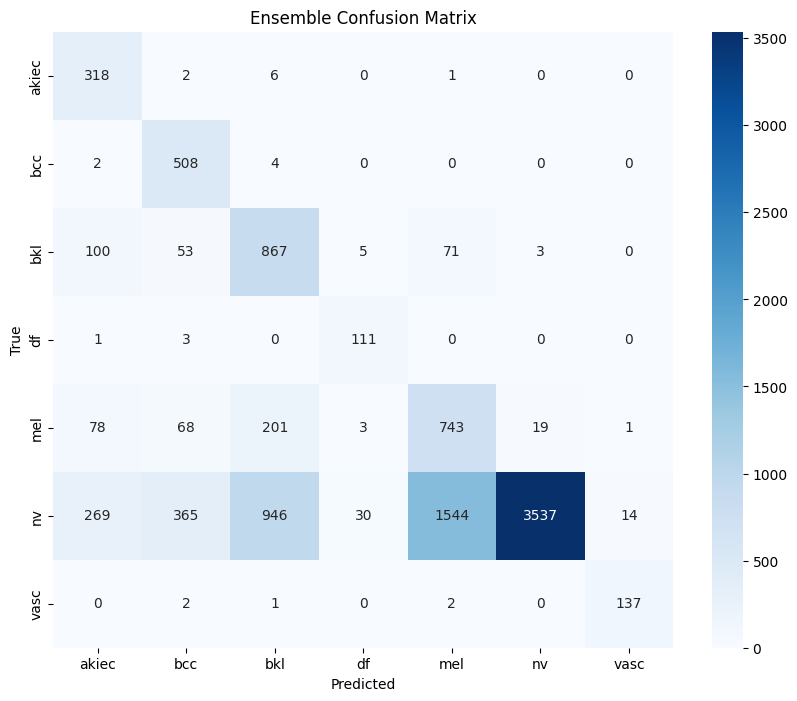

In [14]:
# ============================================================
# 12. ENSEMBLE CONFUSION MATRIX ON FULL VALIDATION SET
# ============================================================

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Combine all validation splits from CV
all_val = df  # because StratifiedKFold splits but we can evaluate full dataset in ensemble mode

true_labels = []
pred_labels = []

for idx in range(len(all_val)):
    row = all_val.iloc[idx]
    
    # load image
    img_id = row["image_id"]
    
    # Find full path
    img_path = None
    for folder in ["HAM10000_images_part_1", "HAM10000_images_part_2"]:
        p = os.path.join(CONFIG["root"], folder, img_id + ".jpg")
        if os.path.exists(p):
            img_path = p
            break
    
    if img_path is None:
        continue
    
    # preprocess image
    img_tensor = load_image(img_path)
    
    # ensemble prediction
    preds = ensemble_predict(img_tensor)
    
    # get max predicted class
    pred_class = max(preds, key=preds.get)
    
    # true class
    true_class = row["dx"]
    
    true_labels.append(true_class)
    pred_labels.append(pred_class)

# Print classification report
print("=== ENSEMBLE CLASSIFICATION REPORT ===")
print(classification_report(true_labels, pred_labels, labels=CONFIG["classes"]))

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels, labels=CONFIG["classes"])

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CONFIG["classes"],
            yticklabels=CONFIG["classes"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Ensemble Confusion Matrix")
plt.show()


In [17]:
import os
[x for x in os.listdir("C:/Users/sudhe") if x.endswith(".pth")]


['efficientnet_fold_0.pth',
 'efficientnet_fold_1.pth',
 'efficientnet_fold_2.pth']

In [18]:
try:
    print("CONFIG img_size =", CONFIG["img_size"])
except:
    print("CONFIG not found. Trying model input...")

try:
    print("Model expected img size =", model.backbone.default_cfg['input_size'])
except:
    print("Model not loaded yet.")


CONFIG img_size = 256
Model not loaded yet.


In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

y_true = []
y_pred = []

print("Evaluating on full dataset...")

for idx in range(len(df)):
    row = df.iloc[idx]

    img_id = row["image_id"]
    true_class = row["dx"]

    # locate image file
    img_path = None
    for folder in ["HAM10000_images_part_1", "HAM10000_images_part_2"]:
        p = os.path.join(CONFIG["root"], folder, img_id + ".jpg")
        if os.path.exists(p):
            img_path = p
            break

    if img_path is None:
        continue

    # load image (YOUR function)
    img_tensor = load_image(img_path)

    # ensemble prediction (YOUR function)
    preds = ensemble_predict(img_tensor)

    pred_class = max(preds, key=preds.get)

    y_true.append(true_class)
    y_pred.append(pred_class)



Evaluating on full dataset...


In [23]:
print("=== ENSEMBLE CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, labels=CONFIG["classes"]))


=== ENSEMBLE CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       akiec       0.41      0.97      0.58       327
         bcc       0.51      0.99      0.67       514
         bkl       0.43      0.79      0.56      1099
          df       0.74      0.97      0.84       115
         mel       0.31      0.67      0.43      1113
          nv       0.99      0.53      0.69      6705
        vasc       0.90      0.96      0.93       142

    accuracy                           0.62     10015
   macro avg       0.61      0.84      0.67     10015
weighted avg       0.81      0.62      0.65     10015



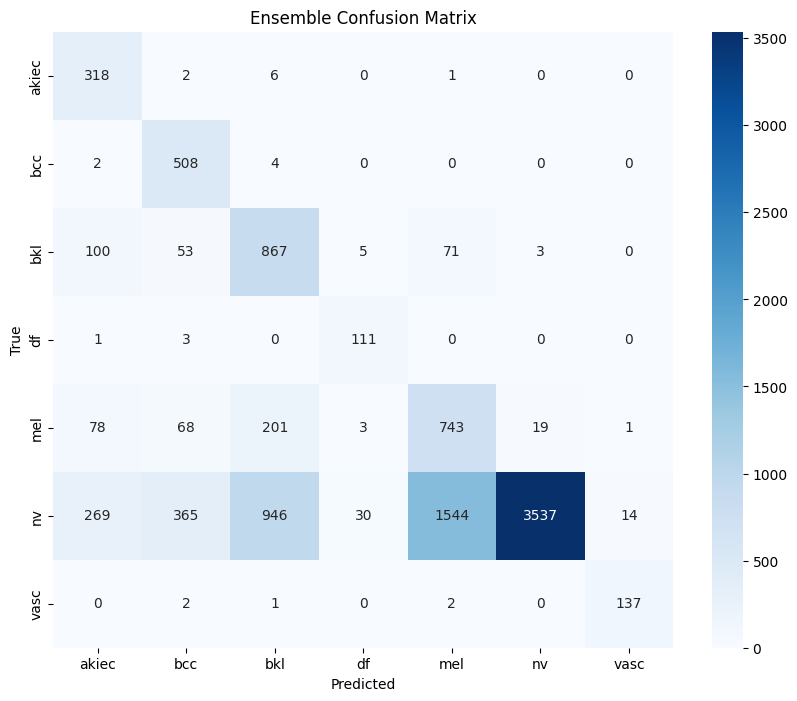

In [24]:
cm = confusion_matrix(y_true, y_pred, labels=CONFIG["classes"])

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CONFIG["classes"],
            yticklabels=CONFIG["classes"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Ensemble Confusion Matrix")
plt.show()


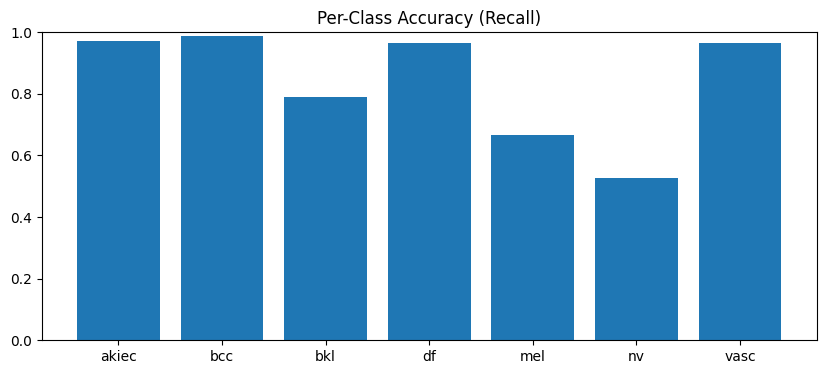

In [25]:
import pandas as pd

report = classification_report(y_true, y_pred, labels=CONFIG["classes"], output_dict=True)
class_acc = {cls: report[cls]["recall"] for cls in CONFIG["classes"]}

plt.figure(figsize=(10,4))
plt.bar(class_acc.keys(), class_acc.values())
plt.title("Per-Class Accuracy (Recall)")
plt.ylim(0,1)
plt.show()


In [26]:
# inside ensemble_predict
return preds, avg_prob  # <-- return probability array


SyntaxError: 'return' outside function (1997916912.py, line 2)